Explore NEE distribution
reuse code from raster_distribution_check.ipynb


This notebook may use fluxcom nee data instead of fluxcom-xbase, please check before run

### NEE pixel value distribution for all over the US in 4 season

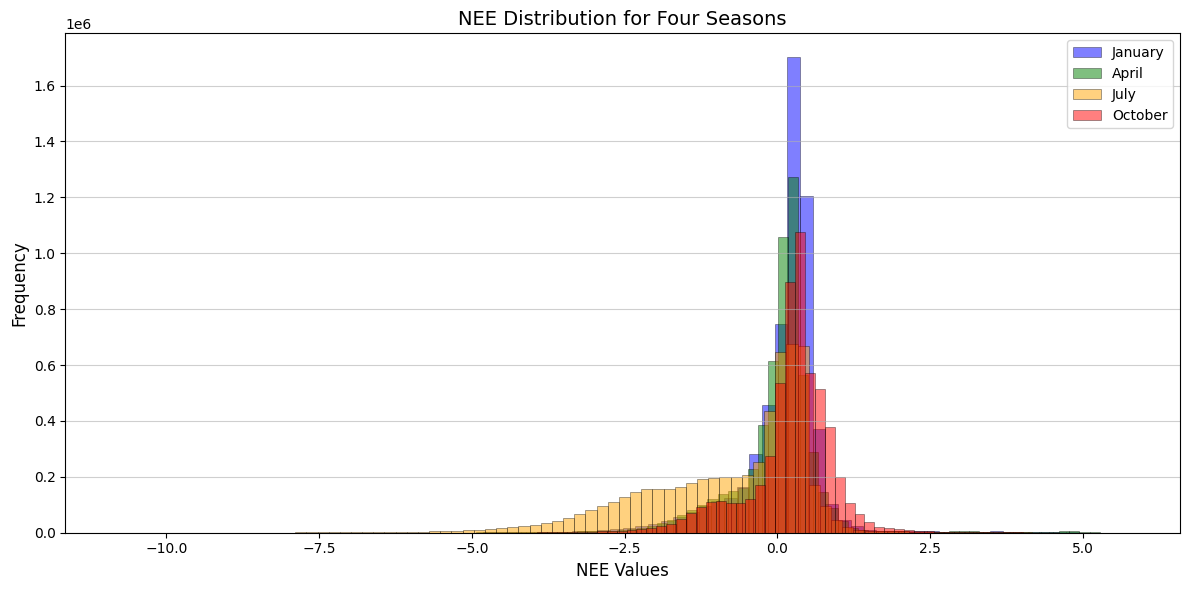

In [7]:
import rasterio
import xarray as xr
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt

# Plot the pixel count / pixel number histograms
bins=80
year = '2004'
month = '01'
year_month = year + month
title=f"Raster Value Distribution in Percentage for NEE, {year_month}"

original_nee_file_path = f'../gis/NEE_FLUX-X/NEE_{year_month[:4]}_005_monthly.nc'


variable = 'NEE'
ds = xr.open_dataset(original_nee_file_path)
# original_nee = ds[variable][int(year_month[4:]) - 1].values  # Extract data for the specified month

# valid_original = original_nee[(~np.isnan(original_nee))]

# # Calculate total number of pixels in the raster
# total_pixels_original = original_nee.size
# # Plot histogram of NEE distribution
# plt.figure(figsize=(12, 6))
# plt.hist(valid_original, bins=bins, color='blue', alpha=0.7, edgecolor='black')
# # Plot histogram of NEE distribution for four seasons (months 1, 4, 7, 10)

seasonal_months = [1, 4, 7, 10]
colors = ['blue', 'green', 'orange', 'red']
labels = ['January', 'April', 'July', 'October']

plt.figure(figsize=(12, 6))
for month, color, label in zip(seasonal_months, colors, labels):
    seasonal_nee = ds[variable][month - 1].values  # Extract data for the specified month
    valid_seasonal = seasonal_nee[(~np.isnan(seasonal_nee))]
    plt.hist(valid_seasonal, bins=bins, color=color, alpha=0.5, edgecolor='black', label=label, linewidth=0.5)

plt.title("NEE Distribution for Four Seasons", fontsize=14)
plt.xlabel('NEE Values', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.6)
plt.tight_layout()
plt.show()


### NEE distribution for a typical MSA

In [8]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import rasterstats as rstats
import xarray as xr
import matplotlib.pyplot as plt
import constants

In [11]:
from rasterio.transform import Affine

In [ ]:
msa_gdf_crsaea = gpd.read_file(constants.MSA_REGION_FILE)
nee_crs = constants.NEE_CRS
nee_orig_transform = constants.NEE_FLUXX_TRANSFORM

# make sure msa and nee are in same crs
msa_gdf_crs4326 = msa_gdf_crsaea.to_crs(nee_crs)

In [14]:
region_list = list(constants.CLIMATE_ZONE.keys())

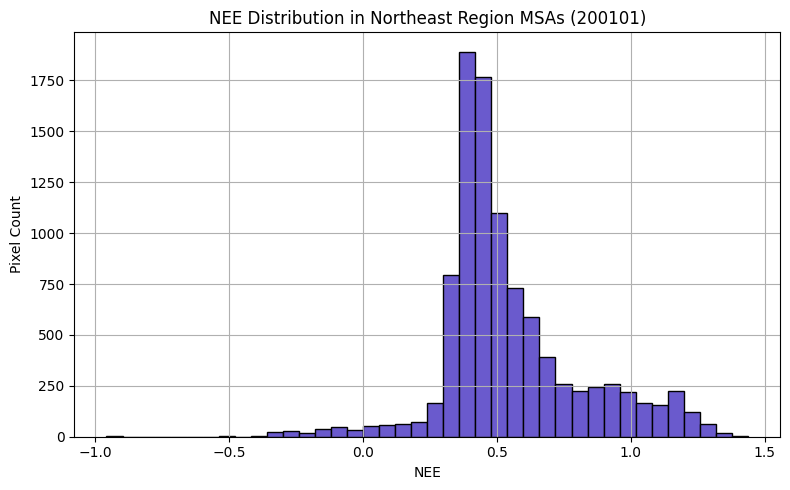

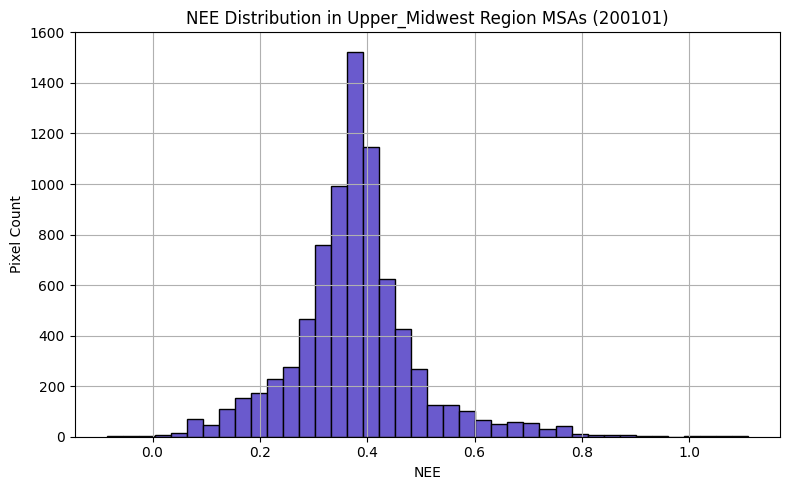

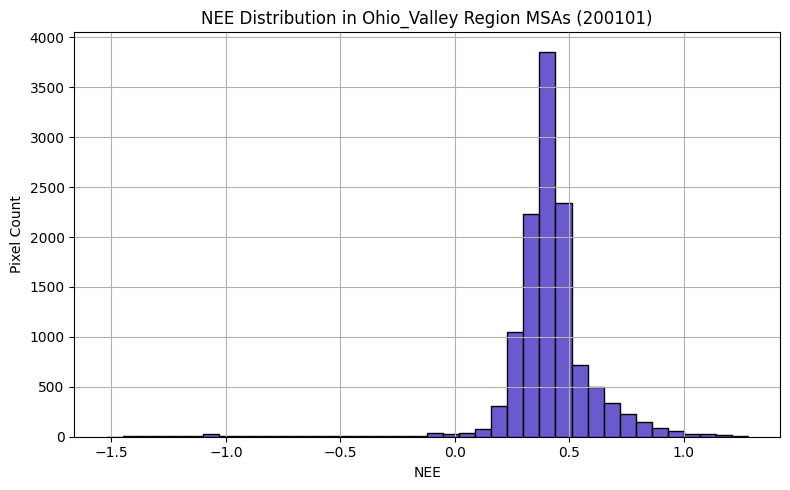

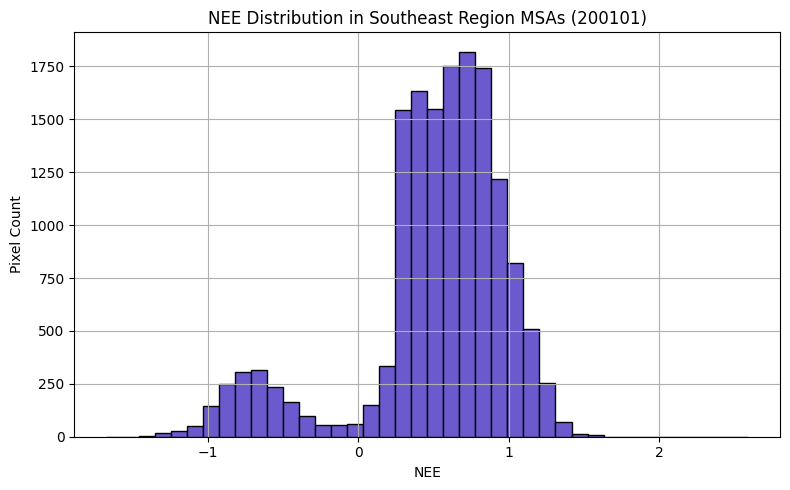

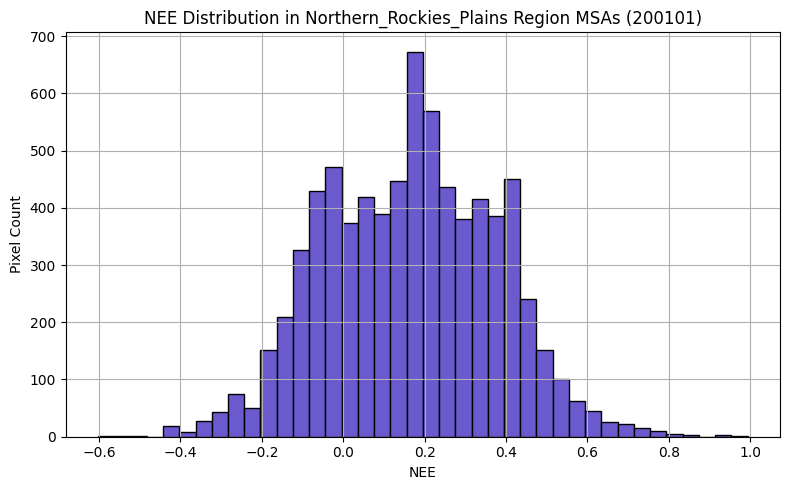

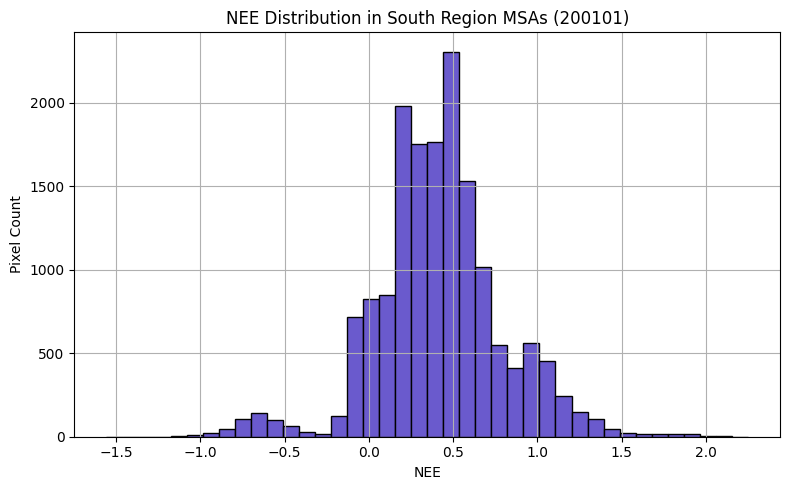

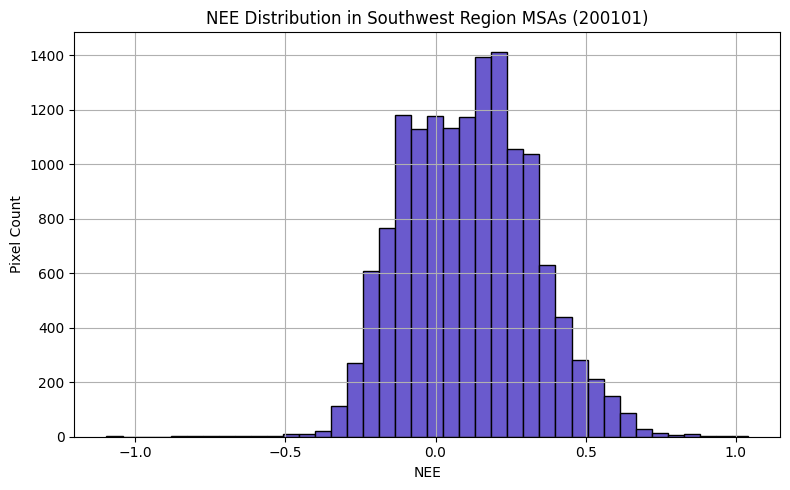

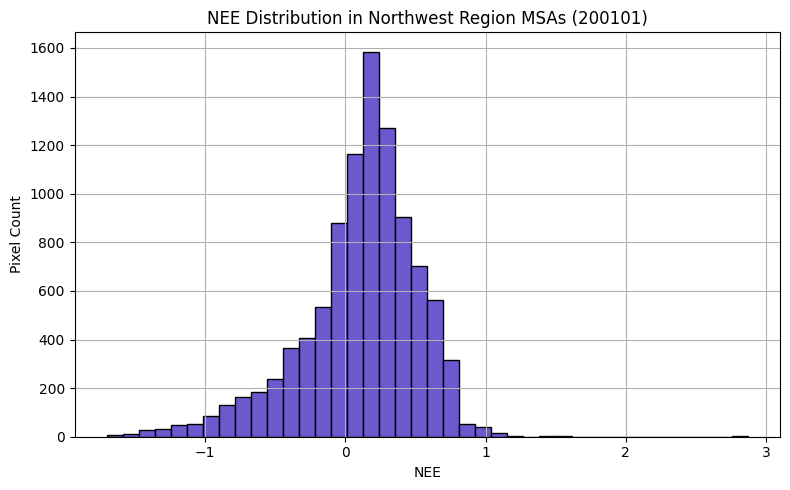

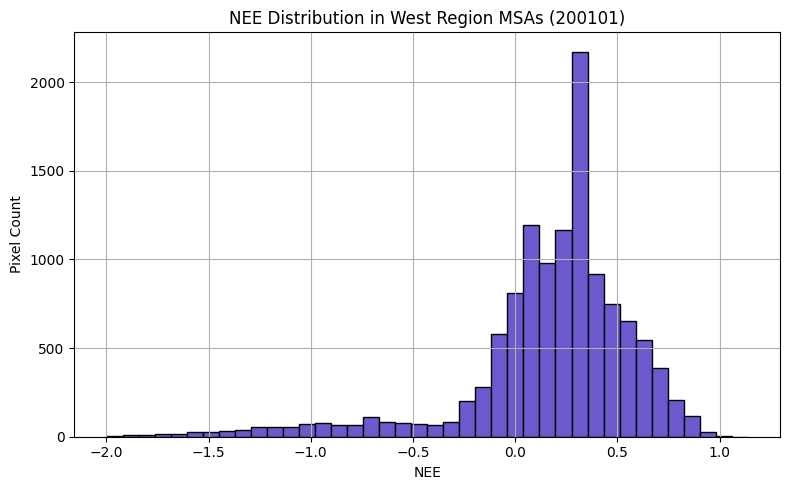

In [17]:
import xarray as xr
import geopandas as gpd
import rasterio
import rasterio.features
import rasterio.transform
import numpy as np
import matplotlib.pyplot as plt

# --- Input paths ---
year_month = '200101'
# nee_file = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year_month[:4]}.nc'
nee_file = f'../gis/NEE_FLUX-X/NEE_{year_month[:4]}_005_monthly.nc'
msa_gdf = msa_gdf_crs4326 

# Read NEE from NetCDF ---
ds = xr.open_dataset(nee_file)
nee_data = ds['NEE'][int(year_month[4:])-1]  # Assuming 12 months, select by index 0-based

# --- Loop over regions ---
for region in region_list:
    # Filter MSAs for this region
    msa_region = msa_gdf[msa_gdf['region'] == region]
    if msa_region.empty:
        print(f"No MSAs found for region: {region}")
        continue

    # Rasterize region MSA shapes
    mask = rasterio.features.rasterize(
        [(geom, 1) for geom in msa_region.geometry],
        out_shape=nee_data.shape,
        transform=nee_orig_transform,
        fill=0,
        dtype=np.uint8
    )

    # Apply mask to NEE
    masked_nee = np.where(mask == 1, nee_data.values, np.nan)

    # Plot histogram
    plt.figure(figsize=(8, 5))
    plt.hist(masked_nee[~np.isnan(masked_nee)], bins=40, color='slateblue', edgecolor='black')
    plt.title(f'NEE Distribution in {region.title()} Region MSAs ({year_month})')
    plt.xlabel('NEE')
    plt.ylabel('Pixel Count')
    plt.grid(True)
    plt.tight_layout()
    plt.show()



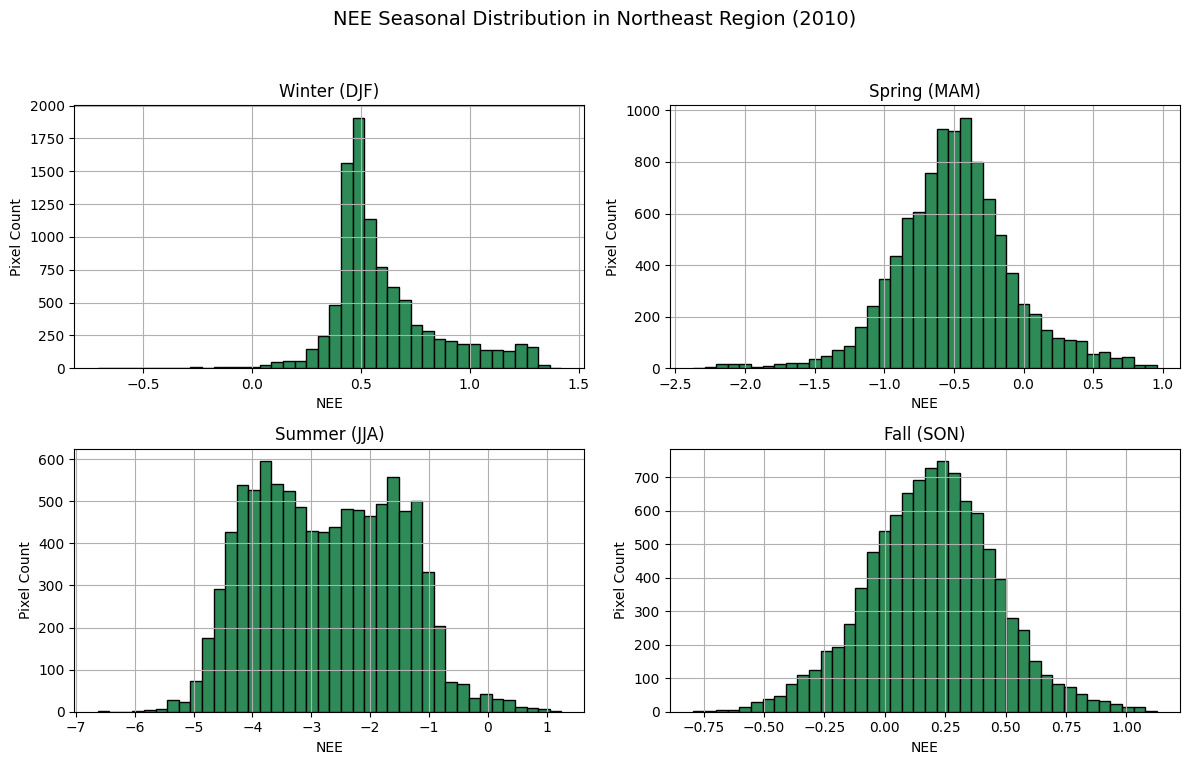

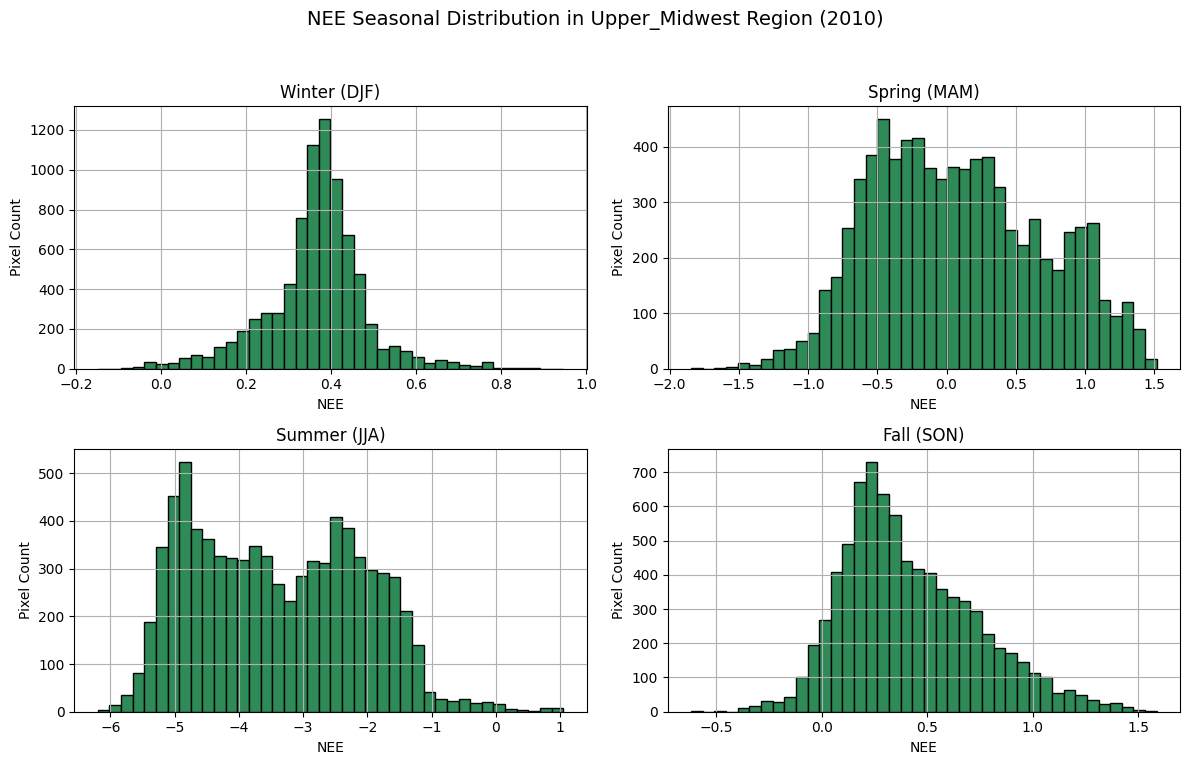

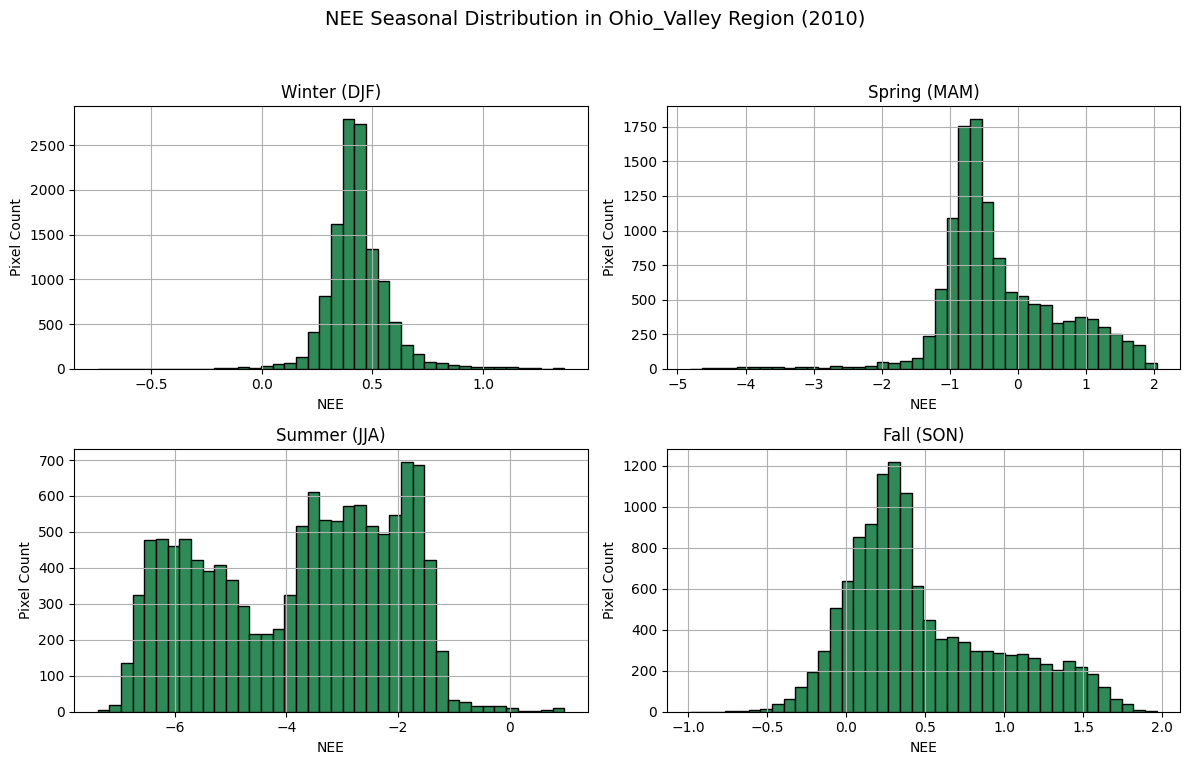

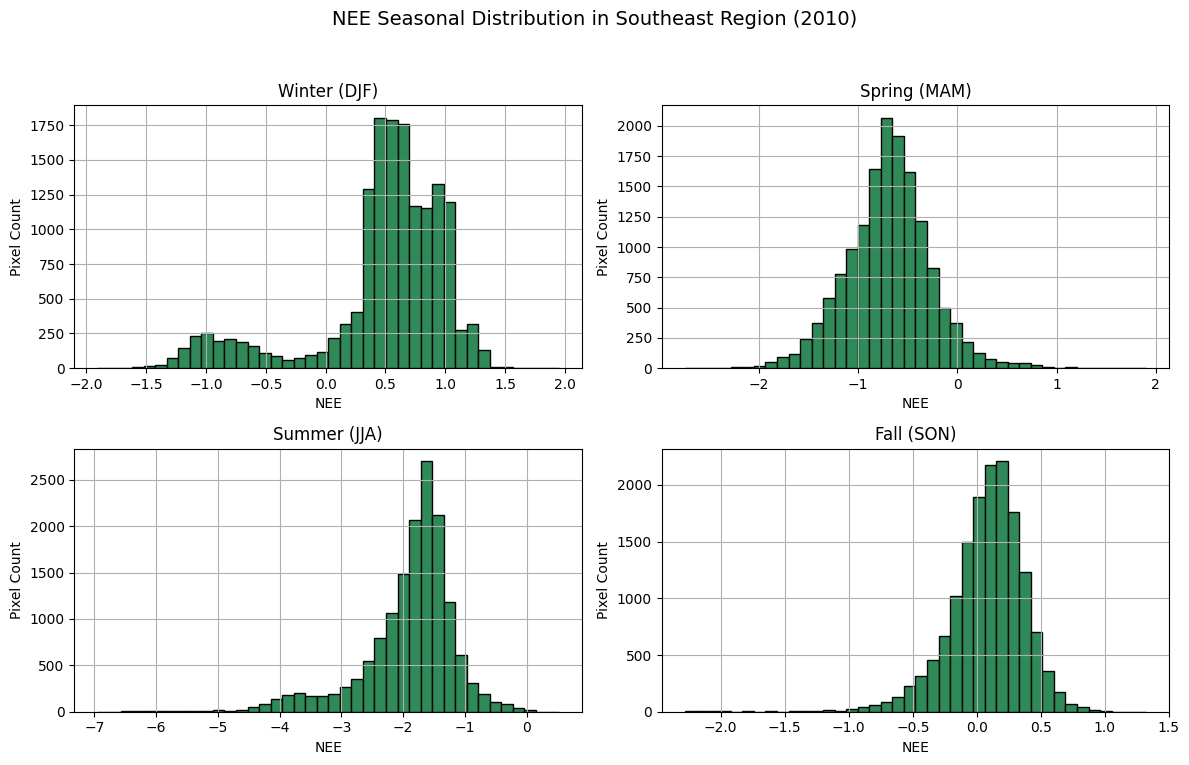

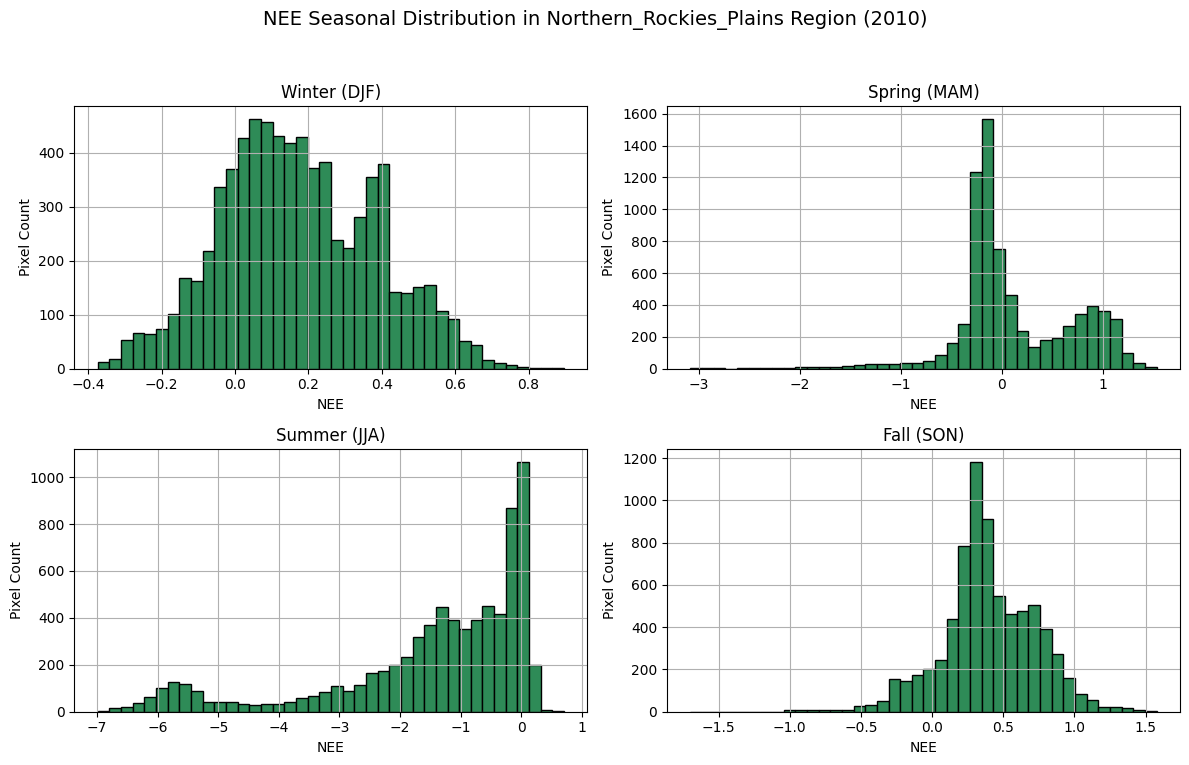

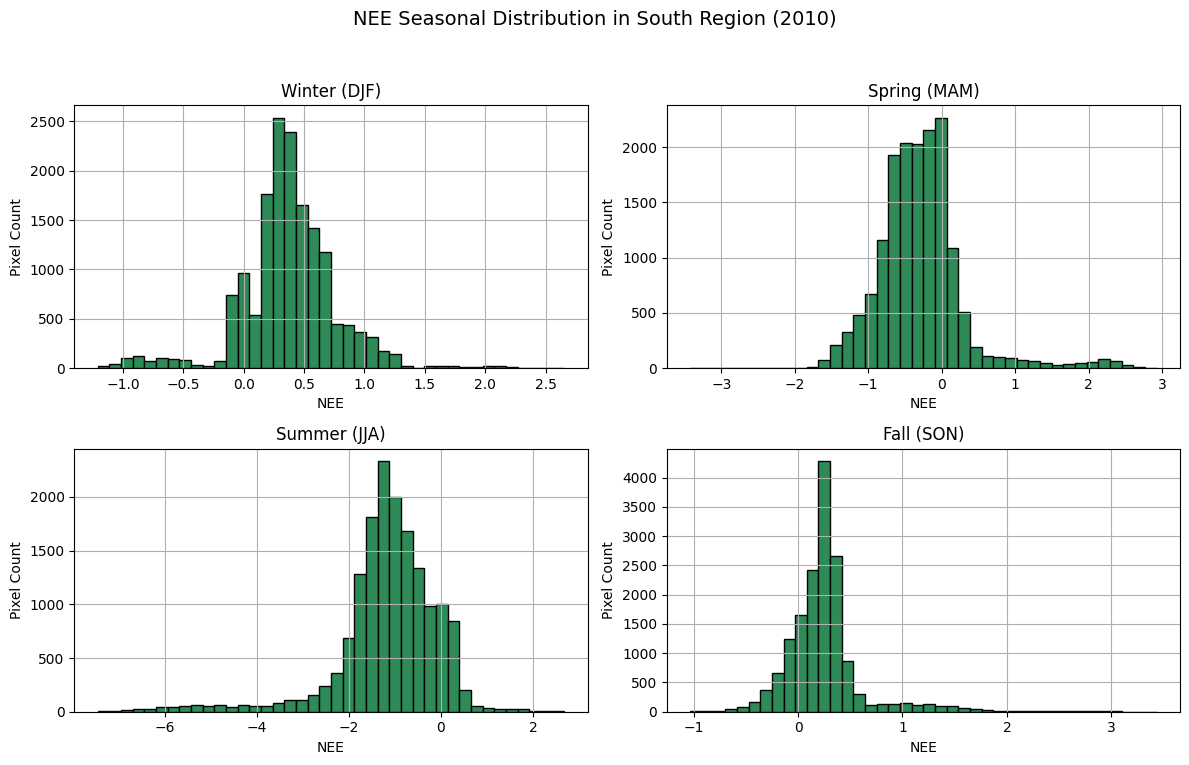

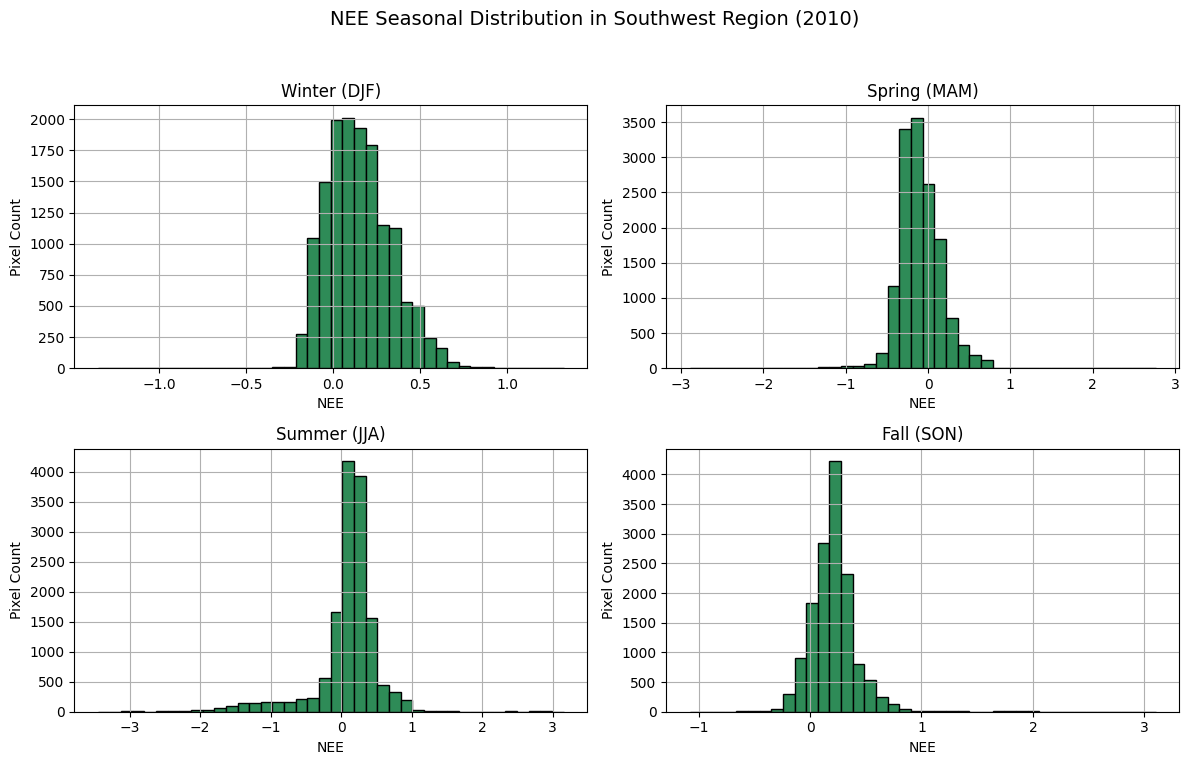

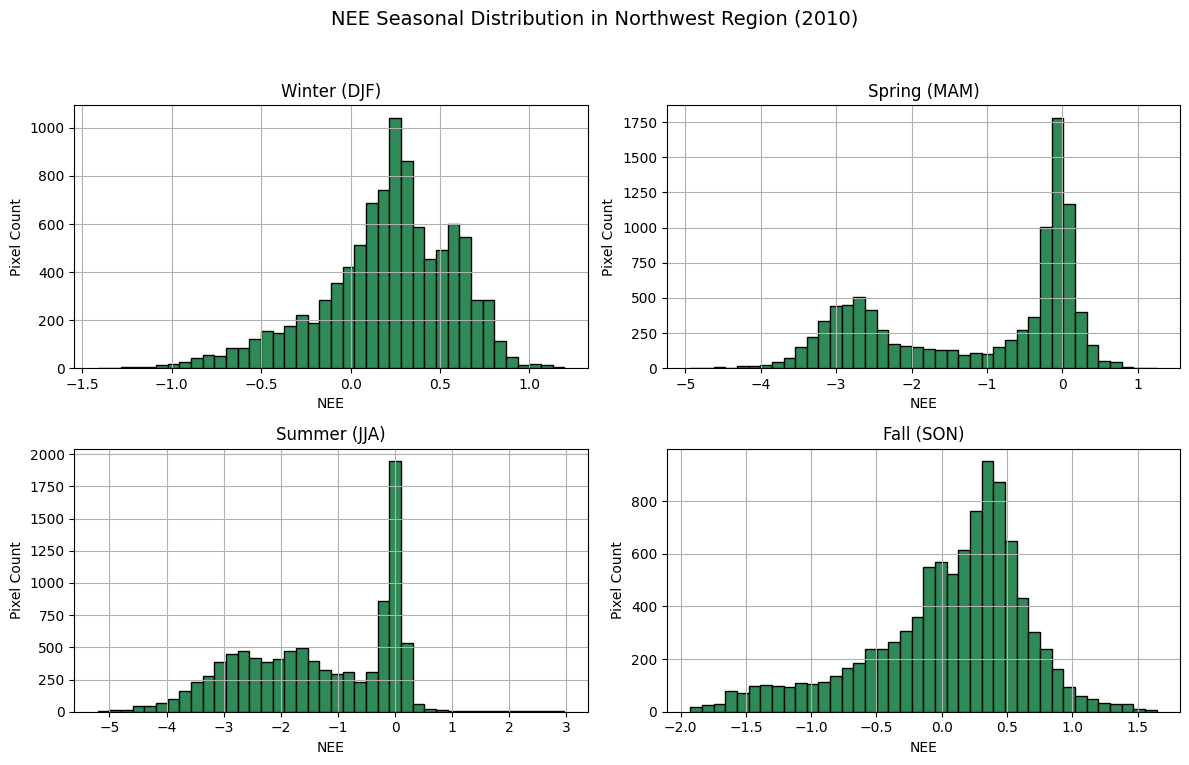

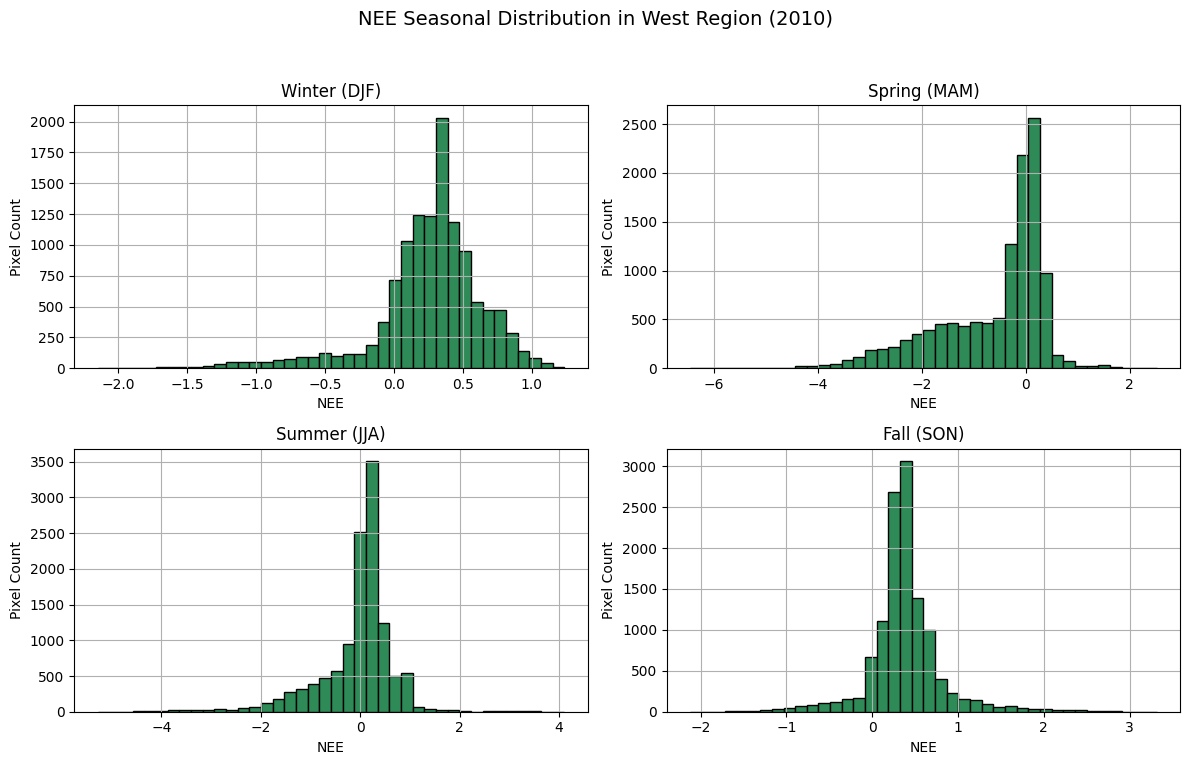

In [18]:
import xarray as xr
import geopandas as gpd
import rasterio
import rasterio.features
import rasterio.transform
import numpy as np
import matplotlib.pyplot as plt

# --- Input ---
year = '2010'
# nee_file = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year}.nc'
nee_file = f'../gis/NEE_FLUX-X/NEE_{year}_005_monthly.nc'

# --- Load dataset ---
ds = xr.open_dataset(nee_file)
nee_monthly = ds['NEE']  


# --- Define seasons: month indices are 0-based
seasons = {
    'Winter (DJF)': [11, 0, 1],   # Dec of previous year, Jan, Feb
    'Spring (MAM)': [2, 3, 4],    # Mar, Apr, May
    'Summer (JJA)': [5, 6, 7],    # Jun, Jul, Aug
    'Fall (SON)':   [8, 9, 10]    # Sep, Oct, Nov
}

# --- Loop over regions ---
for region in region_list:
    msa_region = msa_gdf_crs4326[msa_gdf_crs4326['region'] == region]
    if msa_region.empty:
        print(f"No MSAs found for region: {region}")
        continue

    # Rasterize region
    mask = rasterio.features.rasterize(
        [(geom, 1) for geom in msa_region.geometry],
        out_shape=nee_monthly[0].shape,
        transform=nee_orig_transform,
        fill=0,
        dtype=np.uint8
    )

    # --- Plot 4 seasons in subplots ---
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    axs = axs.flatten()

    for i, (season_name, month_idxs) in enumerate(seasons.items()):
        # Average the seasonal months
        seasonal_nee = nee_monthly[month_idxs].mean(dim='time').values

        # Apply mask
        masked_nee = np.where(mask == 1, seasonal_nee, np.nan)

        # Plot histogram
        axs[i].hist(masked_nee[~np.isnan(masked_nee)], bins=40, color='seagreen', edgecolor='black')
        axs[i].set_title(f'{season_name}')
        axs[i].set_xlabel('NEE')
        axs[i].set_ylabel('Pixel Count')
        axs[i].grid(True)

    fig.suptitle(f'NEE Seasonal Distribution in {region.title()} Region ({year})', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


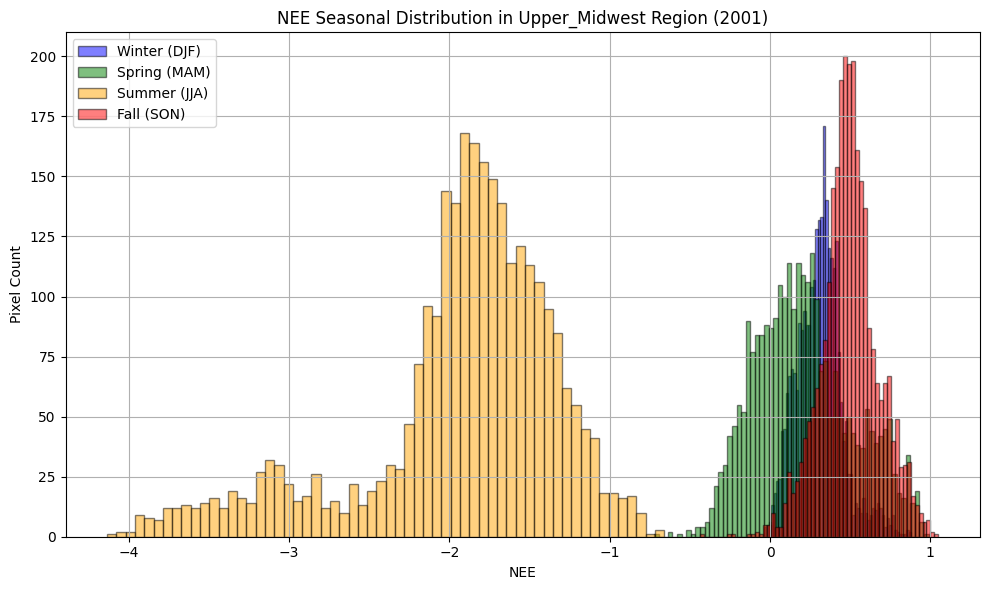

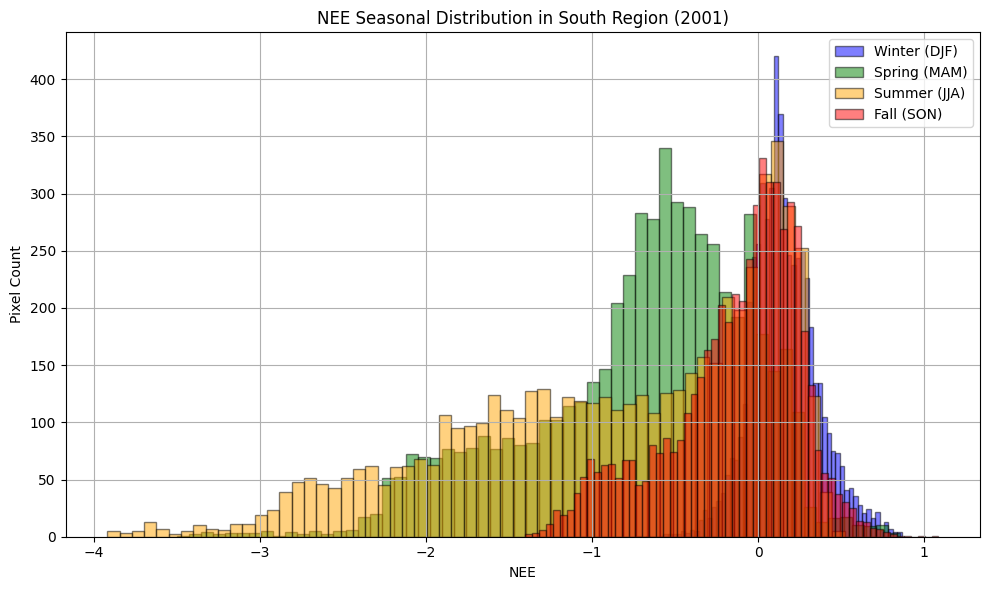

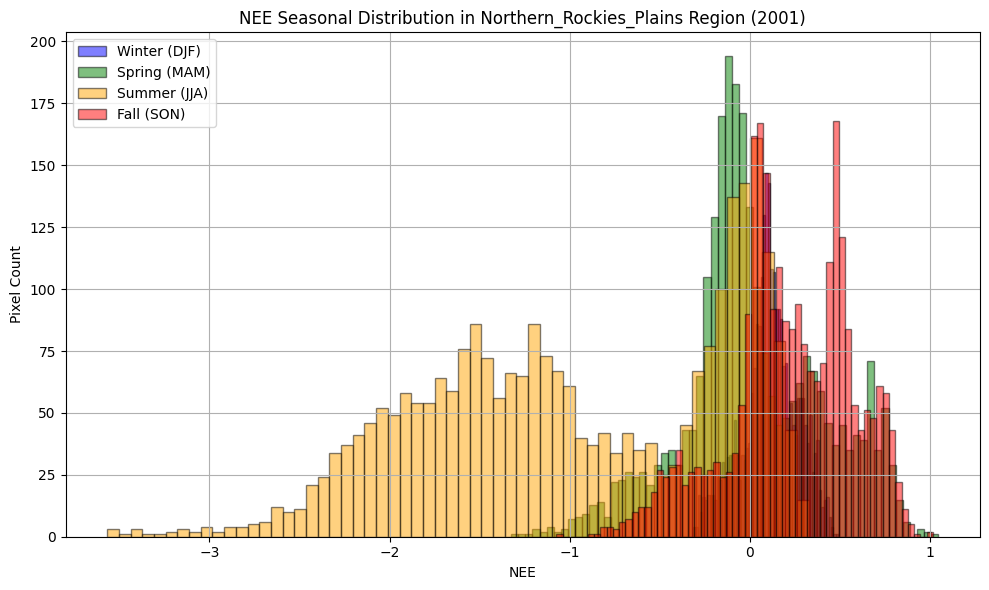

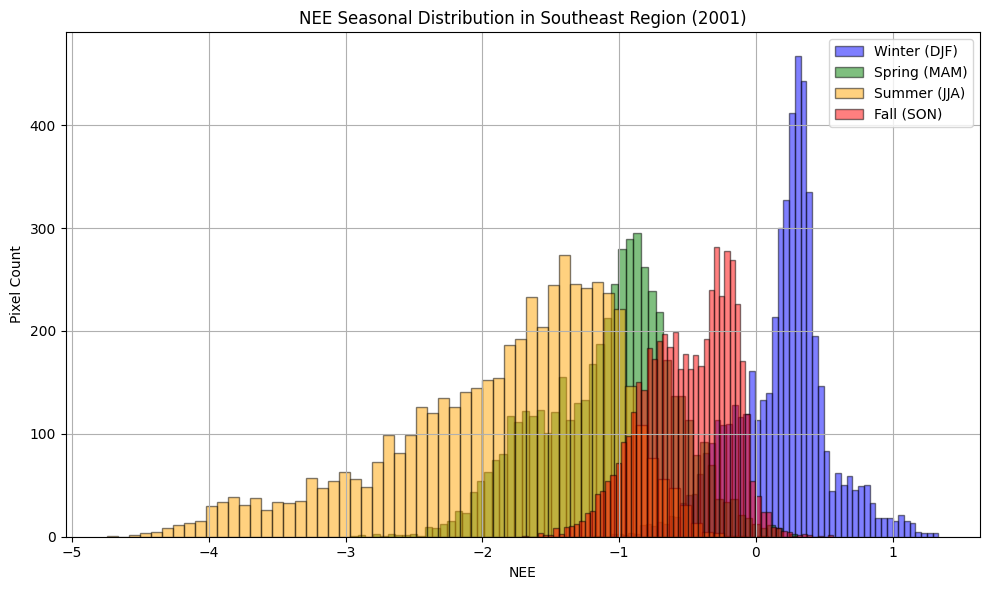

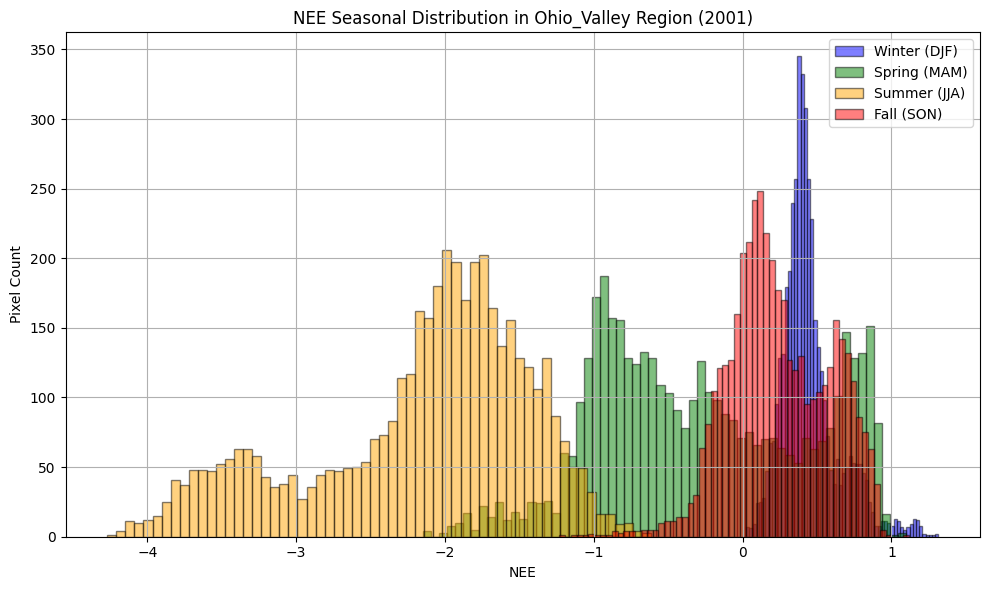

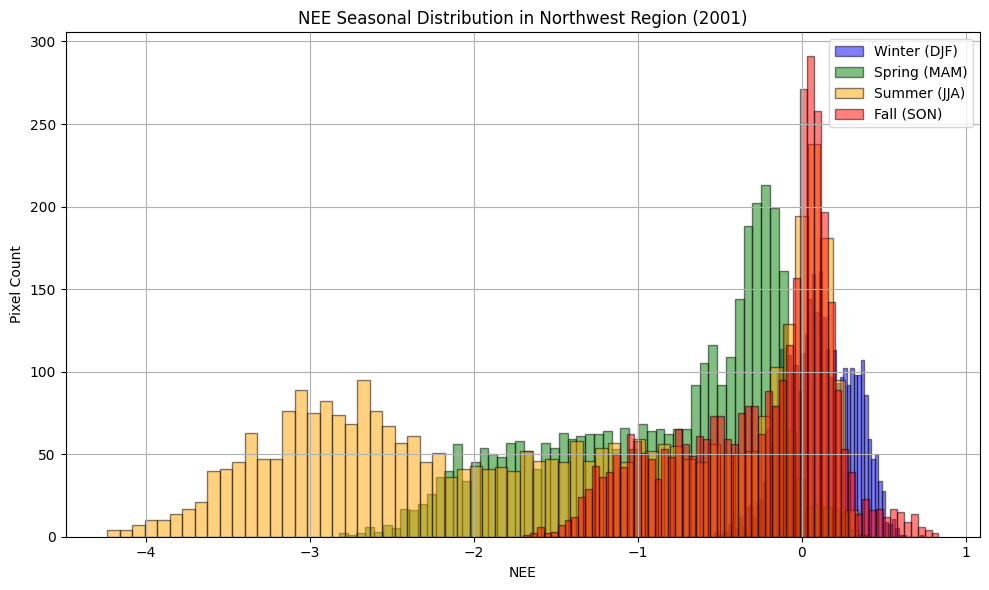

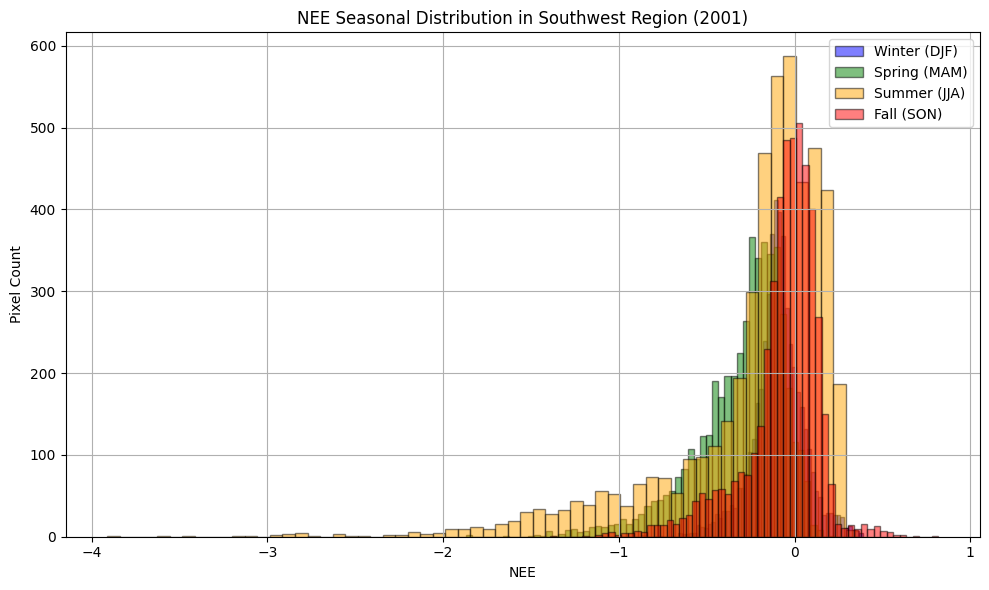

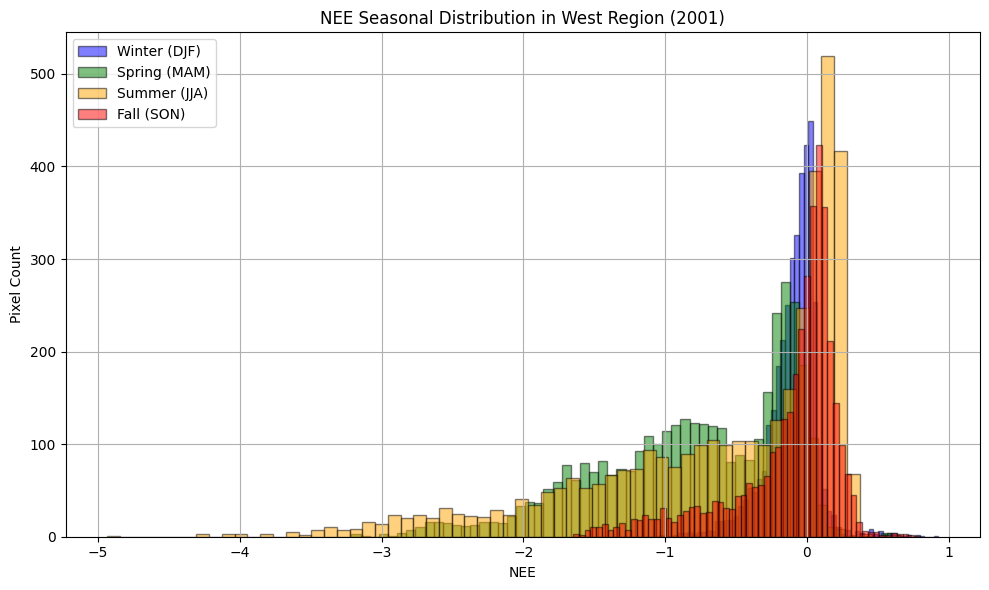

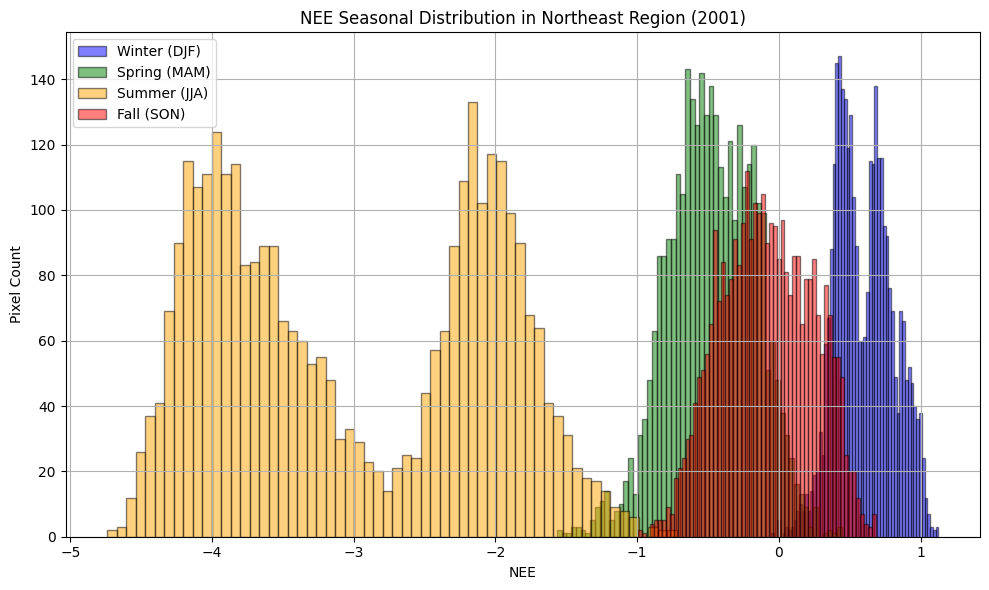

In [ ]:
import xarray as xr
import geopandas as gpd
import rasterio
import rasterio.features
import rasterio.transform
import numpy as np
import matplotlib.pyplot as plt

# --- Inputs ---
year = '2001'
# nee_file = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year}.nc'
nee_file = f'../gis/NEE_FLUX-X/NEE_{year}_005_monthly.nc'
msa_gdf = msa_gdf_crs4326  # Already in EPSG:4326
region_list = msa_gdf['region'].unique().tolist()  # or manually specify

# --- Load dataset ---
ds = xr.open_dataset(nee_file)
nee_monthly = ds['NEE']  # shape: (12, 2160, 4320)

# --- Seasons and colors ---
seasons = {
    'Winter (DJF)': [11, 0, 1],
    'Spring (MAM)': [2, 3, 4],
    'Summer (JJA)': [5, 6, 7],
    'Fall (SON)':   [8, 9, 10]
}
season_colors = ['blue', 'green', 'orange', 'red']

# --- Loop over regions ---
for region in region_list:
    msa_region = msa_gdf[msa_gdf['region'] == region]
    if msa_region.empty:
        print(f"[!] No MSAs found for region: {region}")
        continue

    # Rasterize the MSA region
    mask = rasterio.features.rasterize(
        [(geom, 1) for geom in msa_region.geometry],
        out_shape=nee_monthly[0].shape,
        transform=nee_orig_transform,
        fill=0,
        dtype=np.uint8
    )

    # Begin plotting
    plt.figure(figsize=(10, 6))

    for (season_name, months), color in zip(seasons.items(), season_colors):
        # Average the NEE over 3 months
        seasonal_nee = nee_monthly[months].mean(dim='time').values

        # Apply the mask
        masked_nee = np.where(mask == 1, seasonal_nee, np.nan)
        values = masked_nee[~np.isnan(masked_nee)]

        # Plot histogram
        plt.hist(values, bins=60, alpha=0.5, color=color, edgecolor='black', label=season_name)

    plt.title(f'NEE Seasonal Distribution in {region.title()} Region ({year})')
    plt.xlabel('NEE')
    plt.ylabel('Pixel Count')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    # plt.show()
    plt.savefig(f'../figures/NEE_explore/NEE_seasonal_distribution_{region}_{year}.png', dpi=300, bbox_inches='tight')


different climate zones has very different seasonal distribution pattern
ohio valley and southeast has some similarity
southwest and west has some similarity

In [35]:
msa_name_area = pd.read_csv('../data/intermedia/msa_name_area.csv')

In [ ]:
msa_name_area.describe()


,Unnamed: 0,area_km2
count,383.00000,383.000000
mean,191.00000,6690.295003
std,110.70682,7009.754770
min,0.00000,406.895693
25%,95.50000,2455.377737
50%,191.00000,4439.228827
75%,286.50000,8234.937285
max,382.00000,70986.459750


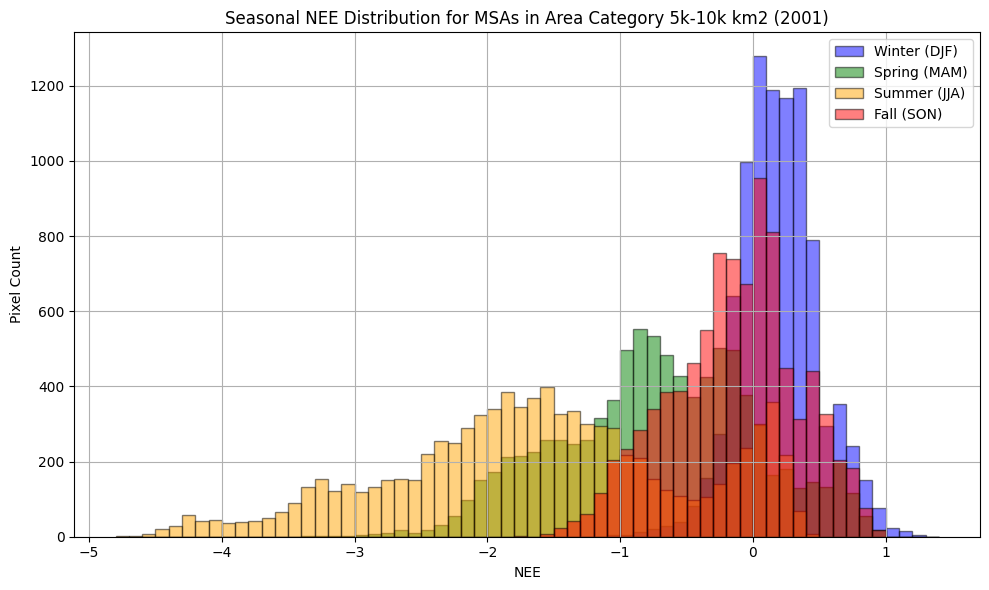

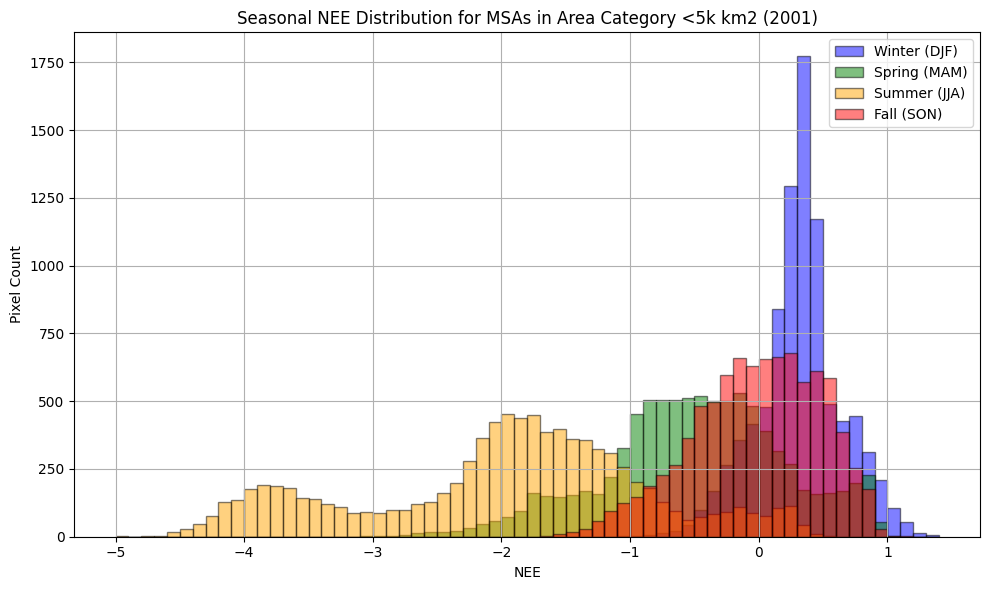

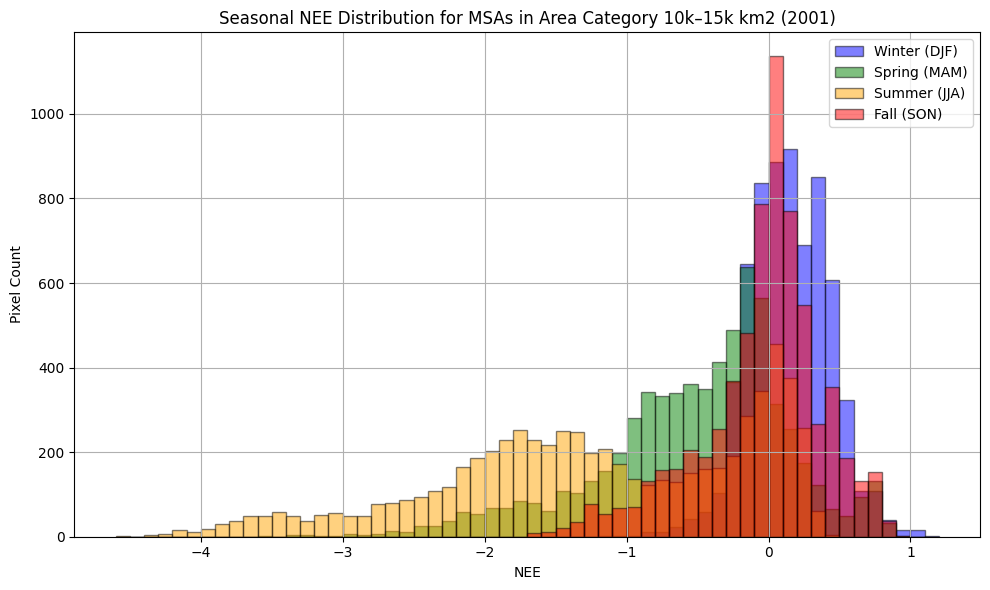

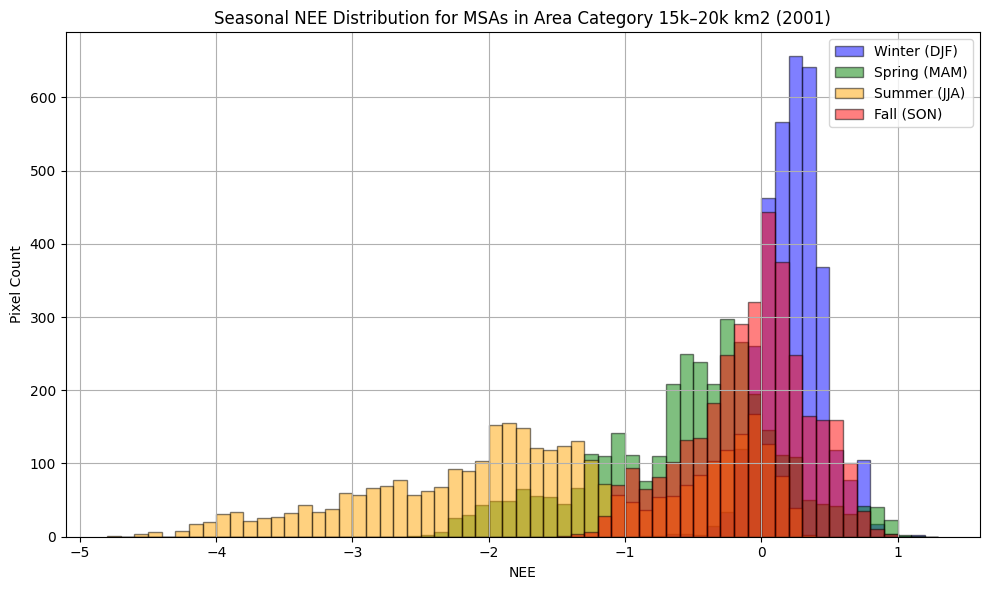

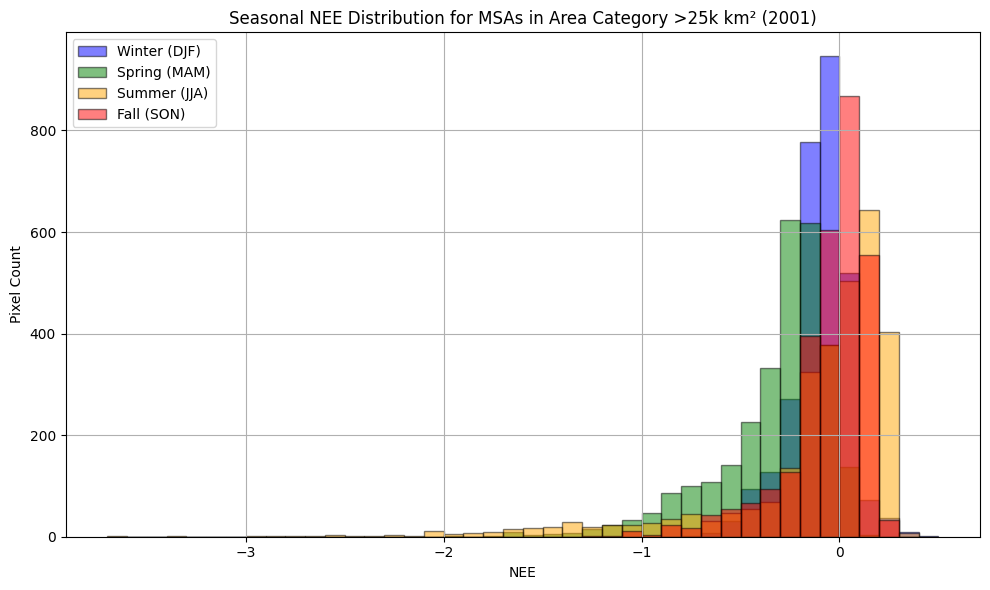

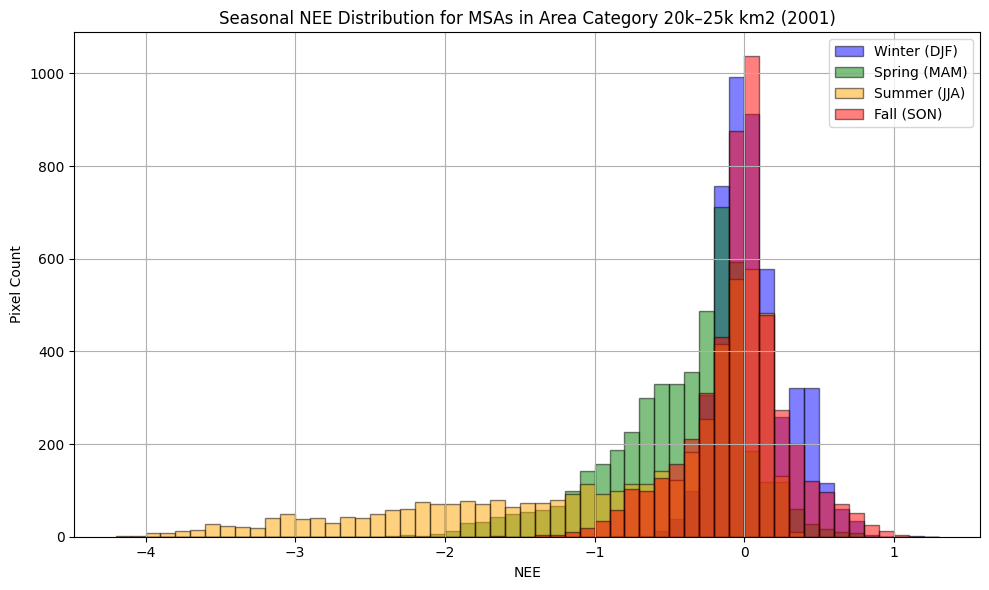

In [37]:
import pandas as pd
import xarray as xr
import geopandas as gpd
import rasterio
import rasterio.features
import rasterio.transform
import numpy as np
import matplotlib.pyplot as plt

# --- Load MSA area info and merge with shapefile ---
msa_area_df = pd.read_csv('../data/intermedia/msa_name_area.csv')  # must have 'NAMELSAD' and 'area_km2'
msa_gdf = msa_gdf_crs4326.merge(msa_area_df, on='NAMELSAD')

# --- Define area categories ---
bins = [0, 5000,10000,15000,20000,25000, np.inf]
labels = ['<5k km2', '5k-10k km2', '10k–15k km2', '15k–20k km2', '20k–25k km2', '>25k km²']
msa_gdf['area_category'] = pd.cut(msa_gdf['area_km2'], bins=bins, labels=labels)

area_category_list = msa_gdf['area_category'].dropna().unique()

# --- Load NEE data ---
year = '2001'
nee_file = f'../gis/NEE/NEE.RS.FP-NONE.MLM-ALL.METEO-NONE.4320_2160.monthly.{year}.nc'
ds = xr.open_dataset(nee_file)
nee_monthly = ds['NEE']

# --- Seasons and colors ---
seasons = {
    'Winter (DJF)': [11, 0, 1],
    'Spring (MAM)': [2, 3, 4],
    'Summer (JJA)': [5, 6, 7],
    'Fall (SON)':   [8, 9, 10]
}
season_colors = ['blue', 'green', 'orange', 'red']

# --- Loop by area category ---
for area_cat in area_category_list:
    msa_group = msa_gdf[msa_gdf['area_category'] == area_cat]
    if msa_group.empty:
        continue

    # Rasterize MSAs in this area category
    mask = rasterio.features.rasterize(
        [(geom, 1) for geom in msa_group.geometry],
        out_shape=nee_monthly[0].shape,
        transform=nee_orig_transform,
        fill=0,
        dtype=np.uint8
    )

    # Step 1: Collect seasonal values
    seasonal_values = []
    for months in seasons.values():
        seasonal_nee = nee_monthly[months].mean(dim='time').values
        masked_nee = np.where(mask == 1, seasonal_nee, np.nan)
        values = masked_nee[~np.isnan(masked_nee)]
        seasonal_values.append(values)

    # Step 2: Compute global bins across all seasons in this category
    all_values_concat = np.concatenate(seasonal_values)
    bin_width = 0.1
    bin_min = np.floor(np.nanmin(all_values_concat) / bin_width) * bin_width
    bin_max = np.ceil(np.nanmax(all_values_concat) / bin_width) * bin_width
    bins = np.arange(bin_min, bin_max + bin_width, bin_width)

    # Step 3: Plot histograms
    plt.figure(figsize=(10, 6))
    for (season_name, _), values, color in zip(seasons.items(), seasonal_values, season_colors):
        plt.hist(values, bins=bins, alpha=0.5, color=color, edgecolor='black', label=season_name)

    plt.title(f'Seasonal NEE Distribution for MSAs in Area Category {area_cat} ({year})')
    plt.xlabel('NEE')
    plt.ylabel('Pixel Count')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


MSA of area <5k km2 has a bit more value around 0, means they have more urbanized area without forestration and NEE
no obvious different pattern of NEE value distribution for MSA with area 20k km2 or smaller